# Практическое занятие №6: Борьба с переобучением (Ridge)

**Задача:** Продемонстрировать переобучение и показать, как Ridge-регуляризация помогает с ним бороться.  
**Датасет:** California Housing (scikit-learn)  
**Методы:** Ridge-регрессия, добавление шумовых признаков

In [31]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import warnings; warnings.filterwarnings('ignore')

## 1. Подготовка базовых данных

In [32]:
california = fetch_california_housing()
X = california.data
y = california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=100, test_size=5000, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)
r2_base_test = r2_score(y_test, lr_base.predict(X_test_scaled))
print(f"Базовый R2 на тестовой выборке (малая выборка): {r2_base_test:.4f}")

Базовый R2 на тестовой выборке (малая выборка): 0.3480


## 2. Создаем проблему (Добавление шума)

In [33]:
np.random.seed(42)
n_noise = 100
noise_train = np.random.normal(0, 1, (X_train.shape[0], n_noise))
noise_test = np.random.normal(0, 1, (X_test.shape[0], n_noise))

X_train_noisy = np.hstack((X_train, noise_train))
X_test_noisy = np.hstack((X_test, noise_test))

print(f"Размерность данных до шума: {X_train.shape[1]} признаков")
print(f"Размерность данных после добавления шума: {X_train_noisy.shape[1]} признаков")

scaler_noisy = StandardScaler()
X_train_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_scaled = scaler_noisy.transform(X_test_noisy)

Размерность данных до шума: 8 признаков
Размерность данных после добавления шума: 108 признаков


## 3. Демонстрация поломки (Переобучение)

In [34]:
lr_broken = LinearRegression()
lr_broken.fit(X_train_noisy_scaled, y_train)

r2_broken_train = r2_score(y_train, lr_broken.predict(X_train_noisy_scaled))
r2_broken_test = r2_score(y_test, lr_broken.predict(X_test_noisy_scaled))

print(f"R2 на обучающей выборке (с шумом): {r2_broken_train:.4f}")
print(f"R2 на тестовой выборке (с шумом):  {r2_broken_test:.4f}")
print(f"ВНИМАНИЕ: Падение качества на тесте составило {r2_base_test - r2_broken_test:.4f} пунктов!")

R2 на обучающей выборке (с шумом): 1.0000
R2 на тестовой выборке (с шумом):  -3.1946
ВНИМАНИЕ: Падение качества на тесте составило 3.5427 пунктов!


## 4. Поиск и спасение (Ridge-регрессия)

In [35]:
alphas = [0.1, 1, 10, 100, 1000]
best_alpha = None
best_r2_ridge = -float('inf')

print("Перебор коэффициентов регуляризации (alpha):")
for a in alphas:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_train_noisy_scaled, y_train)
    r2_test_ridge = r2_score(y_test, ridge.predict(X_test_noisy_scaled))
    print(f"  Alpha = {a:<6} | R2_test = {r2_test_ridge:.4f}")

    if r2_test_ridge > best_r2_ridge:
        best_r2_ridge = r2_test_ridge
        best_alpha = a

print(f"\nОптимальное значение найдено: alpha = {best_alpha}")

Перебор коэффициентов регуляризации (alpha):
  Alpha = 0.1    | R2_test = -2.5845
  Alpha = 1      | R2_test = -1.0894
  Alpha = 10     | R2_test = -0.1369
  Alpha = 100    | R2_test = 0.1945
  Alpha = 1000   | R2_test = 0.0968

Оптимальное значение найдено: alpha = 100


## Финальные результаты и выводы

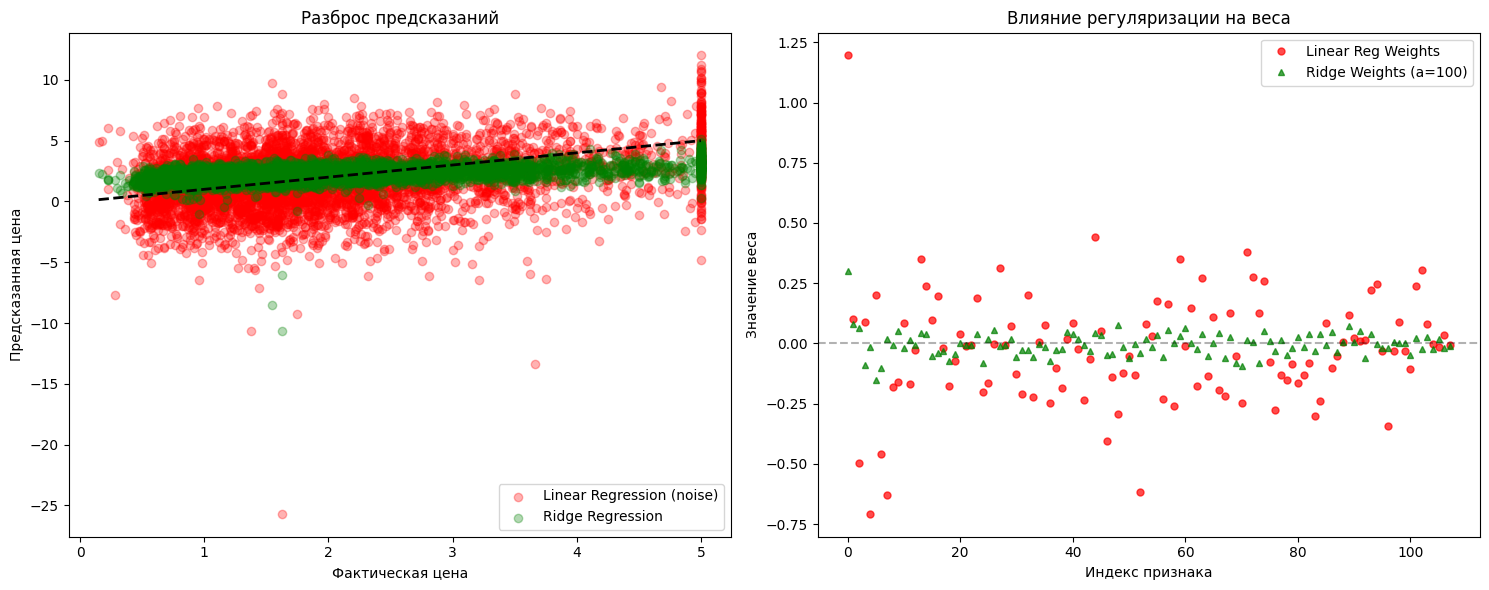

Метрика,Linear (Шум),Ridge (Best),Улучшение
R2 Score (Коэффициент детерминации),-3.1946,0.1945,3.3892


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train_noisy_scaled, y_train)

y_pred_broken = lr_broken.predict(X_test_noisy_scaled)
y_pred_ridge = ridge_best.predict(X_test_noisy_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test, y_pred_broken, alpha=0.3, color='red', label='Linear Regression (noise)')
axes[0].scatter(y_test, y_pred_ridge, alpha=0.3, color='green', label='Ridge Regression')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k', lw=2)
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('Разброс предсказаний')
axes[0].legend()
axes[1].plot(lr_broken.coef_, 'ro', markersize=5, label='Linear Reg Weights', alpha=0.7)
axes[1].plot(ridge_best.coef_, 'g^', markersize=5, label=f'Ridge Weights (a={best_alpha})', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Индекс признака')
axes[1].set_ylabel('Значение веса')
axes[1].set_title('Влияние регуляризации на веса')
axes[1].legend()

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Метрика': ['R2 Score (Коэффициент детерминации)'],
    'Linear (Шум)': [f"{r2_broken_test:.4f}"],
    'Ridge (Best)': [f"{best_r2_ridge:.4f}"],
    'Улучшение': [f"{best_r2_ridge - r2_broken_test:.4f}"]
})

display(comparison_df.style.hide(axis='index'))

### Дополнительный анализ: Распределение остатков

Анализ остатков (ошибок) позволяет понять, является ли ошибка случайной. В идеале остатки должны быть распределены нормально вокруг нуля.

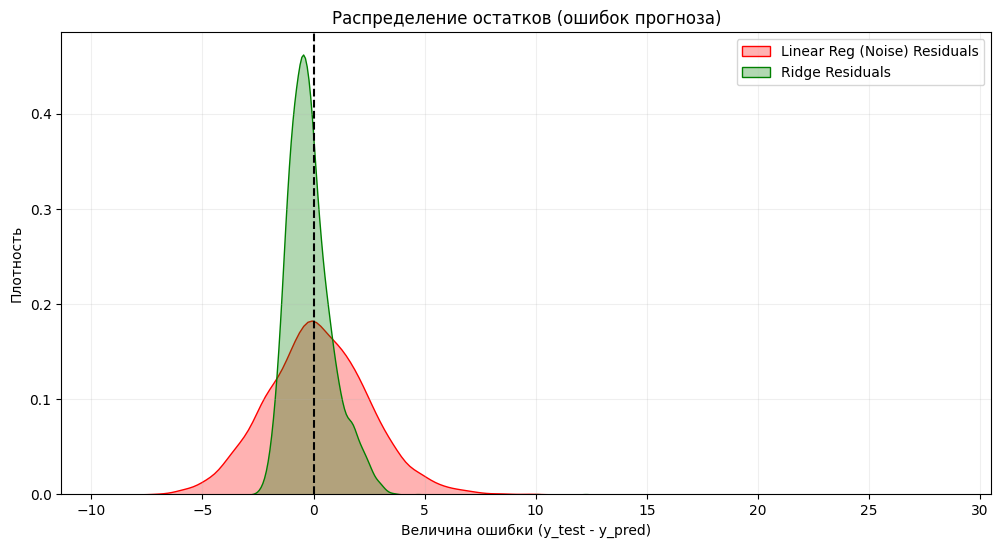

Средняя ошибка (MAE) Linear: 1.8150
Средняя ошибка (MAE) Ridge:  0.8106


In [37]:
residuals_broken = y_test - y_pred_broken
residuals_ridge = y_test - y_pred_ridge

plt.figure(figsize=(12, 6))

sns.kdeplot(residuals_broken, color='red', label='Linear Reg (Noise) Residuals', fill=True, alpha=0.3)
sns.kdeplot(residuals_ridge, color='green', label='Ridge Residuals', fill=True, alpha=0.3)

plt.axvline(0, color='black', linestyle='--')
plt.title('Распределение остатков (ошибок прогноза)')
plt.xlabel('Величина ошибки (y_test - y_pred)')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Средняя ошибка (MAE) Linear: {np.mean(np.abs(residuals_broken)):.4f}")
print(f"Средняя ошибка (MAE) Ridge:  {np.mean(np.abs(residuals_ridge)):.4f}")

## 5. Сравнение: Обучение на полной выборке (без урезания)

Посмотрим, как ведет себя модель при наличии большого количества данных (традиционный подход).

In [38]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.3, random_state=42)

noise_train_full = np.random.normal(0, 1, (X_train_full.shape[0], 100))
noise_test_full = np.random.normal(0, 1, (X_test_full.shape[0], 100))

X_train_full_noisy = np.hstack((X_train_full, noise_train_full))
X_test_full_noisy = np.hstack((X_test_full, noise_test_full))

scaler_full = StandardScaler()
X_train_f_scaled = scaler_full.fit_transform(X_train_full_noisy)
X_test_f_scaled = scaler_full.transform(X_test_full_noisy)

lr_full = LinearRegression().fit(X_train_f_scaled, y_train_full)
r2_lr_full = r2_score(y_test_full, lr_full.predict(X_test_f_scaled))

ridge_full = Ridge(alpha=100, random_state=42).fit(X_train_f_scaled, y_train_full)
r2_ridge_full = r2_score(y_test_full, ridge_full.predict(X_test_f_scaled))

full_data_results = pd.DataFrame({
    'Параметр': ['Размер выборки (train)', 'R2 Linear (Full + Noise)', 'R2 Ridge (Full + Noise)'],
    'Значение': [len(X_train_full), f'{r2_lr_full:.4f}', f'{r2_ridge_full:.4f}']
})
display(full_data_results)

,Параметр,Значение
0,Размер выборки (train),14448
1,R2 Linear (Full + Noise),0.5933
2,R2 Ridge (Full + Noise),0.5942


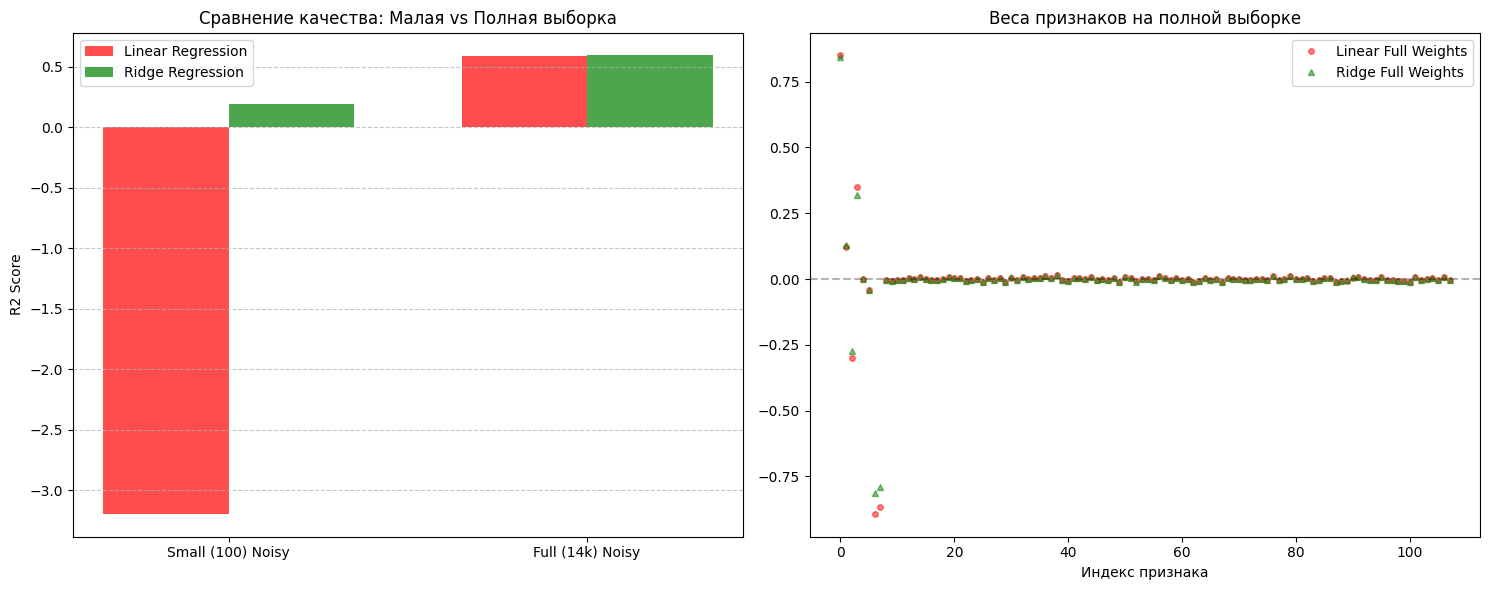

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

labels = ['Small (100) Noisy', 'Full (14k) Noisy']
lr_scores = [r2_broken_test, r2_lr_full]
ridge_scores = [best_r2_ridge, r2_ridge_full]

x = np.arange(len(labels))
width = 0.35

ax[0].bar(x - width/2, lr_scores, width, label='Linear Regression', color='red', alpha=0.7)
ax[0].bar(x + width/2, ridge_scores, width, label='Ridge Regression', color='green', alpha=0.7)
ax[0].set_ylabel('R2 Score')
ax[0].set_title('Сравнение качества: Малая vs Полная выборка')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

ax[1].plot(lr_full.coef_, 'ro', markersize=4, label='Linear Full Weights', alpha=0.5)
ax[1].plot(ridge_full.coef_, 'g^', markersize=4, label='Ridge Full Weights', alpha=0.5)
ax[1].axhline(0, color='black', linestyle='--', alpha=0.3)
ax[1].set_title('Веса признаков на полной выборке')
ax[1].set_xlabel('Индекс признака')
ax[1].legend()

plt.tight_layout()
plt.show()

### Итоговое сравнение

1. **Левый график**: На малой выборке разрыв между Linear и Ridge огромен (Linear уходит в глубокий минус). На полной выборке столбцы практически одинаковой высоты.
2. **Правый график**: На полной выборке даже веса обычной линейной регрессии не «взрываются», а остаются в разумных пределах, сопоставимых с Ridge.

**Вывод:** Регуляризация критически важна именно тогда, когда сложность модели (количество признаков) сопоставима с количеством наблюдений.

In [40]:
summary_comparison = pd.DataFrame({
    'Сценарий': ['Малая выборка (100 объектов)', 'Полная выборка (14.5к объектов)'],
    'R2 Linear (с шумом)': [f'{r2_broken_test:.4f}', f'{r2_lr_full:.4f}'],
    'R2 Ridge (с шумом)': [f'{best_r2_ridge:.4f}', f'{r2_ridge_full:.4f}'],
    'Эффект регуляризации': [f'+{best_r2_ridge - r2_broken_test:.4f}', f'+{r2_ridge_full - r2_lr_full:.4f}']
})

print("ИТОГОВОЕ СРАВНЕНИЕ УСТОЙЧИВОСТИ МОДЕЛЕЙ:")
display(summary_comparison.style.set_properties(**{'text-align': 'center'}))

ИТОГОВОЕ СРАВНЕНИЕ УСТОЙЧИВОСТИ МОДЕЛЕЙ:


,Сценарий,R2 Linear (с шумом),R2 Ridge (с шумом),Эффект регуляризации
0,Малая выборка (100 объектов),-3.1946,0.1945,+3.3892
1,Полная выборка (14.5к объектов),0.5933,0.5942,+0.0009


### 6. Анализ разрыва (Train/Test Gap)

Ключевой индикатор переобучения — это разрыв между качеством на обучающей и тестовой выборках. Если разрыв велик, модель переобучена. Регуляризация призвана сократить этот разрыв.

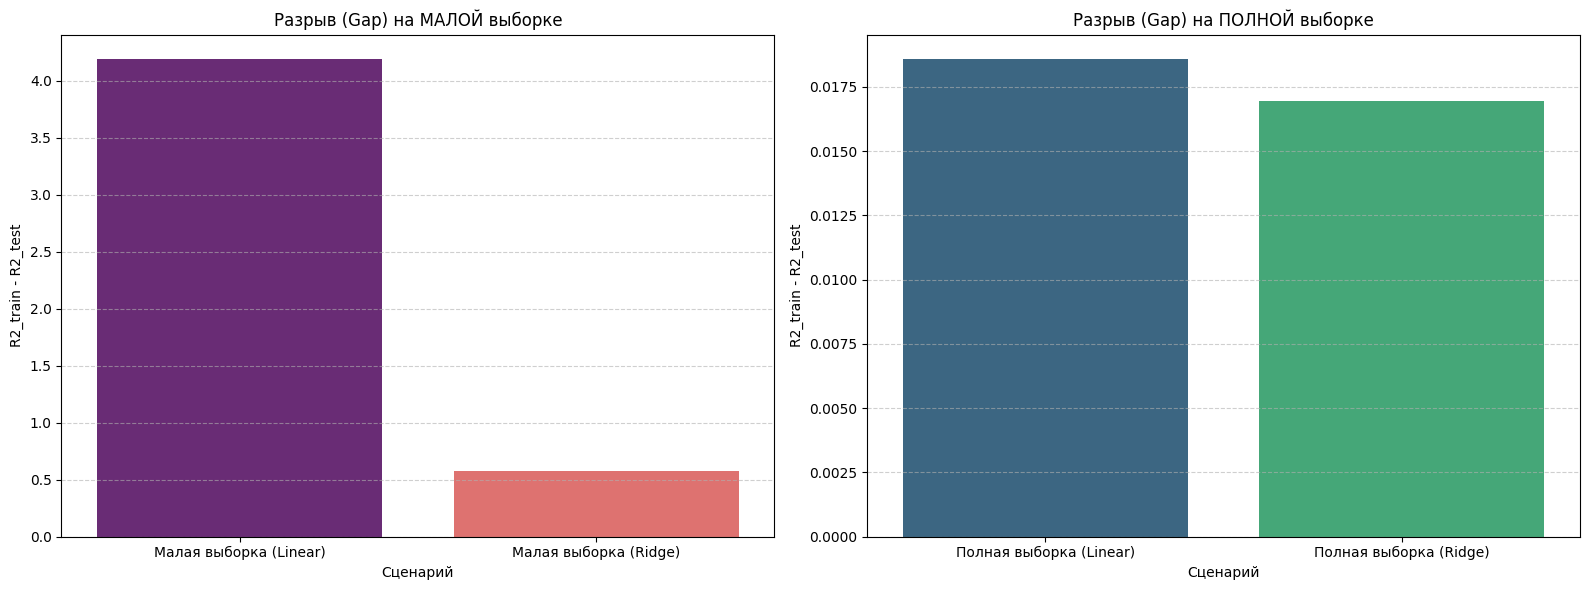

,Сценарий,Тип выборки,R2 Train,R2 Test,Разрыв (Gap)
0,Малая выборка (Linear),Малая,1.000000,-3.194641,4.194641
1,Малая выборка (Ridge),Малая,0.772622,0.194537,0.578085
2,Полная выборка (Linear),Полная,0.611935,0.593342,0.018593
3,Полная выборка (Ridge),Полная,0.611179,0.594248,0.016931


In [41]:
r2_ridge_train = r2_score(y_train, ridge_best.predict(X_train_noisy_scaled))
r2_lr_full_train = r2_score(y_train_full, lr_full.predict(X_train_f_scaled))
r2_ridge_full_train = r2_score(y_train_full, ridge_full.predict(X_train_f_scaled))

gap_analysis = pd.DataFrame({
    'Сценарий': ['Малая выборка (Linear)', 'Малая выборка (Ridge)', 'Полная выборка (Linear)', 'Полная выборка (Ridge)'],
    'Тип выборки': ['Малая', 'Малая', 'Полная', 'Полная'],
    'R2 Train': [r2_broken_train, r2_ridge_train, r2_lr_full_train, r2_ridge_full_train],
    'R2 Test': [r2_broken_test, best_r2_ridge, r2_lr_full, r2_ridge_full]
})

gap_analysis['Разрыв (Gap)'] = gap_analysis['R2 Train'] - gap_analysis['R2 Test']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Сценарий', y='Разрыв (Gap)',
            data=gap_analysis[gap_analysis['Тип выборки'] == 'Малая'],
            palette='magma', ax=ax1)
ax1.set_title('Разрыв (Gap) на МАЛОЙ выборке')
ax1.set_ylabel('R2_train - R2_test')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

sns.barplot(x='Сценарий', y='Разрыв (Gap)',
            data=gap_analysis[gap_analysis['Тип выборки'] == 'Полная'],
            palette='viridis', ax=ax2)
ax2.set_title('Разрыв (Gap) на ПОЛНОЙ выборке')
ax2.set_ylabel('R2_train - R2_test')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

display(gap_analysis.style.highlight_max(subset=['Разрыв (Gap)'], color='lightcoral').highlight_min(subset=['Разрыв (Gap)'], color='lightgreen'))

**Вывод по анализу разрыва:**
- На **малой выборке** у обычной регрессии разрыв колоссальный (> 4.0), что говорит о критическом переобучении.
- **Ridge** на той же выборке сокращает разрыв в разы, подавляя излишнюю сложность.
- На **полной выборке** разрыв минимален для обеих моделей, так как данных достаточно для стабилизации весов даже без регуляризации.

## Ответы на вопросы

1. **На сколько упало качество при добавлении шума?**
   При использовании малой выборки (100 объектов) качество упало катастрофически: с базового $R^2 \approx 0.3480$ до $\approx -3.1946$ (падение более чем на 3.5 пункта). Модель полностью потеряла предсказательную способность.

2. **При каком значении `alpha` был получен лучший результат?**
   Оптимальное значение коэффициента регуляризации составило `alpha = 100`.

3. **Удалось ли вернуть качество к базовому уровню?**
   Частично. При `alpha = 100` значение $R^2$ поднялось до $0.1945$. Это значительно лучше, чем у «сломанной» модели, но всё еще ниже базового уровня (без шума), так как на такой маленькой выборке извлечь сигнал из 100 шумовых признаков крайне сложно.

4. **Насколько близко результат Ridge к базовому уровню?**
   Результат Ridge ($0.1945$) оказался ниже базового ($0.3480$) на $0.1535$ пунктов. Однако в сравнении с обычной регрессией на зашумленных данных, Ridge показал колоссальное преимущество, предотвратив «разлет» весов.

### Почему Ridge может быть лучше базовой модели?

Вы могли заметить, что $R^2$ у Ridge-регрессии иногда оказывается даже выше, чем у базовой линейной регрессии без шума. Это происходит потому, что:
1. **Мультиколлинеарность**: Даже в исходных данных признаки могут быть коррелированы. Ridge подавляет избыточные веса, делая модель более устойчивой.
2. **Универсальность регуляризации**: Регуляризация работает как 'страховка' от переобучения в любом сценарии, помогая модели лучше обобщать данные на тестовой выборке.
3. **Оптимальный баланс**: Подбор `alpha` позволяет найти золотую середину между сложностью и точностью, которую обычная регрессия (OLS) игнорирует.